# Keller and Sinn (2005): Ordinal Analysis of Time Series

Notebook này tái tạo thực nghiệm logistic map và ordinal Feigenbaum diagram trong Figure 3. Thuật toán ordinal được gọi trực tiếp từ `core_ntsa.ordinal_analysis`; notebook chỉ chứa quy trình thực nghiệm.

## 1. Imports

In [1]:
from math import factorial
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "core_ntsa").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core_ntsa.ordinal_analysis import ordinal_analysis

## 2. Experiment Configuration

Tham số được paper chỉ định:

- $r \in [2.8, 4.0]$
- Ordinal order $d=7$
- Delay $\tau=1$

Paper không nêu độ phân giải của lưới tham số, độ dài transient, số điểm giữ lại và điều kiện đầu. Các giá trị bên dưới là lựa chọn của bản tái tạo.

In [2]:
R_MIN = 2.8
R_MAX = 4.0
N_R = 1200

D = 7
TAU = 1

TRANSIENT_LENGTH = 1000
RETAINED_LENGTH = 300
SEED = 42

POINT_SIZE = 0.08
POINT_ALPHA = 0.35

if RETAINED_LENGTH <= D * TAU:
    raise ValueError("RETAINED_LENGTH must be greater than D * TAU.")

## 3. Logistic Map Definition

Logistic map được xác định bởi $x_{t+1}=r x_t(1-x_t)$. Mỗi quỹ đạo bỏ phần transient trước khi giữ lại các trạng thái tiệm cận.

In [3]:
def logistic_map(x, r):
    """Evaluate one logistic-map step."""
    return r * x * (1.0 - x)


def generate_orbit(r, x0, transient, retained):
    """Generate one asymptotic logistic-map orbit."""
    orbit = np.empty(retained, dtype=np.float64)
    state = float(x0)

    for step in range(transient + retained):
        state = logistic_map(state, r)
        if step >= transient:
            orbit[step - transient] = state

    return orbit

## 4. Sanity Check of Logistic Dynamics

Ba chế độ được kiểm tra trước khi chạy toàn bộ lưới: ổn định tại $r=2.9$, period-doubling tại $r=3.5$, và hỗn loạn tại $r=4.0$.

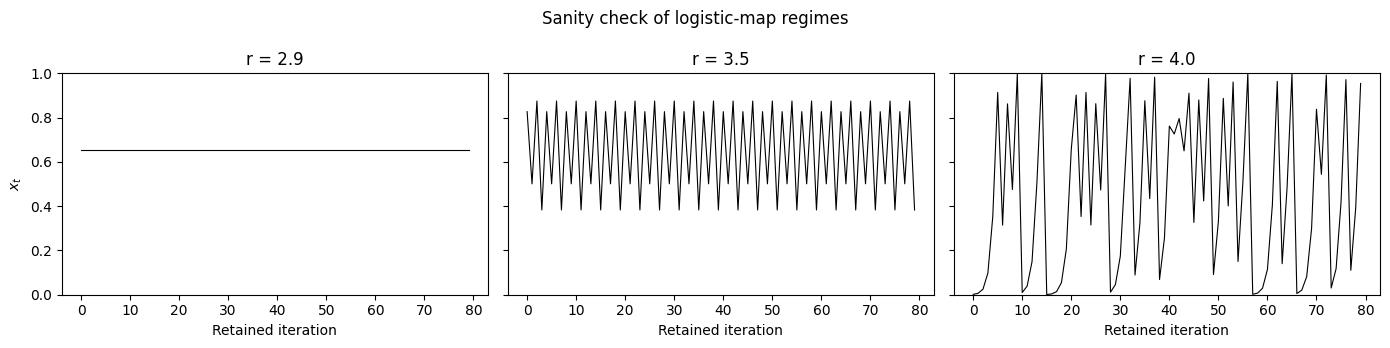

In [4]:
sanity_r_values = (2.9, 3.5, 4.0)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

for axis, r_value in zip(axes, sanity_r_values):
    orbit = generate_orbit(r_value, 0.37, 300, 80)
    axis.plot(orbit, color="black", linewidth=0.8)
    axis.set_title(f"r = {r_value:.1f}")
    axis.set_xlabel("Retained iteration")
    axis.set_ylim(0.0, 1.0)

axes[0].set_ylabel(r"$x_t$")
fig.suptitle("Sanity check of logistic-map regimes")
fig.tight_layout()
plt.show()

Kết quả mong đợi là một fixed point tại $r=2.9$, quỹ đạo tuần hoàn tại $r=3.5$, và quỹ đạo bất quy tắc tại $r=4.0$.

## 5. Parameter Grid and Asymptotic Orbits

Mỗi giá trị $r$ nhận một điều kiện đầu xác định bởi `SEED`. Quỹ đạo sau transient được lưu một lần và tái sử dụng cho cả hai biểu đồ.

In [5]:
rng = np.random.default_rng(SEED)
r_values = np.linspace(R_MIN, R_MAX, N_R)
initial_conditions = rng.uniform(0.1, 0.9, size=N_R)
orbits = np.empty((N_R, RETAINED_LENGTH), dtype=np.float64)

for row, (r_value, x0) in enumerate(zip(r_values, initial_conditions)):
    orbits[row] = generate_orbit(
        r_value,
        x0,
        TRANSIENT_LENGTH,
        RETAINED_LENGTH,
    )

print(f"Parameter values: {r_values.size}")
print(f"Orbit matrix shape: {orbits.shape}")

Parameter values: 1200
Orbit matrix shape: (1200, 300)


## 6. Original Feigenbaum Diagram

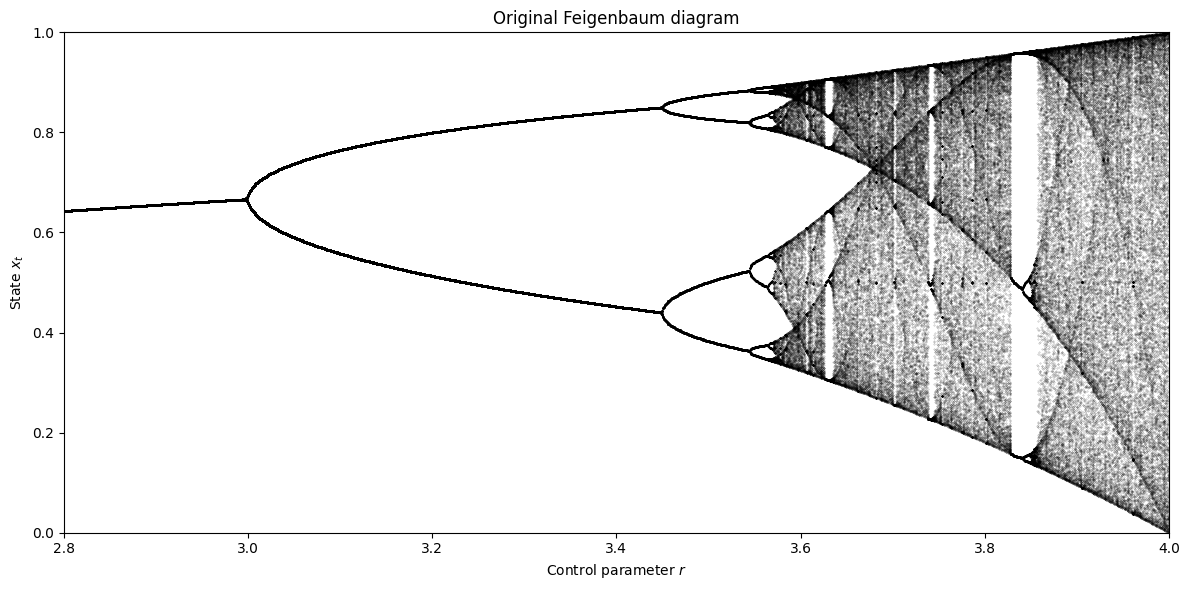

In [6]:
raw_r_coordinates = np.repeat(r_values, RETAINED_LENGTH)

fig, axis = plt.subplots(figsize=(12, 6))
axis.scatter(
    raw_r_coordinates,
    orbits.ravel(),
    s=POINT_SIZE,
    alpha=POINT_ALPHA,
    color="black",
    rasterized=True,
)
axis.set(
    title="Original Feigenbaum diagram",
    xlabel=r"Control parameter $r$",
    ylabel=r"State $x_t$",
    xlim=(R_MIN, R_MAX),
    ylim=(0.0, 1.0),
)
fig.tight_layout()
plt.show()

## 7. Ordinal Transformation

Mỗi retained orbit được biến đổi bằng core Keller với $d=7$ và $\tau=1$. Số điểm ordinal trên mỗi quỹ đạo bằng `RETAINED_LENGTH - D * TAU`.

In [7]:
ordinal_length = RETAINED_LENGTH - D * TAU
ordinal_orbits = np.empty((N_R, ordinal_length), dtype=np.float64)
observed_pattern_counts = np.empty(N_R, dtype=np.int64)

for row, orbit in enumerate(orbits):
    result = ordinal_analysis(orbit, d=D, tau=TAU)
    ordinal_orbits[row] = result.ordinal_values
    observed_pattern_counts[row] = np.unique(
        result.ordinal_numbers
    ).size

if not np.all((ordinal_orbits >= 0.0) & (ordinal_orbits < 1.0)):
    raise RuntimeError("Ordinal values must lie in [0, 1).")

print(f"Ordinal orbit matrix shape: {ordinal_orbits.shape}")
print(f"Possible patterns: {factorial(D + 1)}")

Ordinal orbit matrix shape: (1200, 293)
Possible patterns: 40320


## 8. Ordinal Feigenbaum Diagram

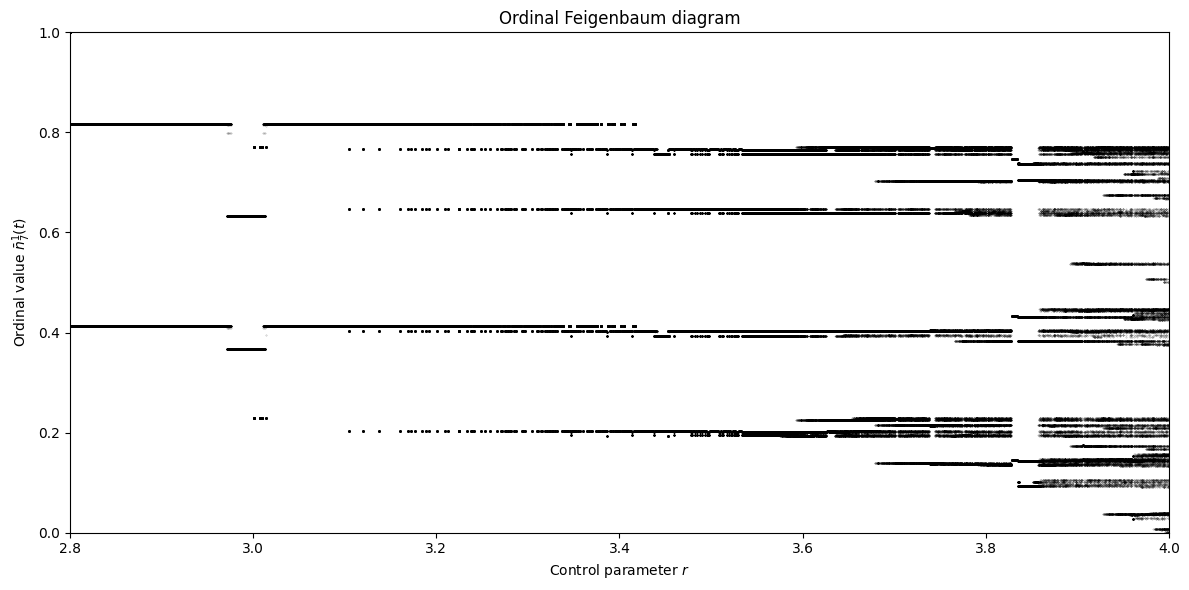

In [8]:
ordinal_r_coordinates = np.repeat(r_values, ordinal_length)

fig, axis = plt.subplots(figsize=(12, 6))
axis.scatter(
    ordinal_r_coordinates,
    ordinal_orbits.ravel(),
    s=POINT_SIZE,
    alpha=POINT_ALPHA,
    color="black",
    rasterized=True,
)
axis.set(
    title="Ordinal Feigenbaum diagram",
    xlabel=r"Control parameter $r$",
    ylabel=r"Ordinal value $\bar{n}_7^1(t)$",
    xlim=(R_MIN, R_MAX),
    ylim=(0.0, 1.0),
)
fig.tight_layout()
plt.show()

## 9. Side-by-Side Comparison

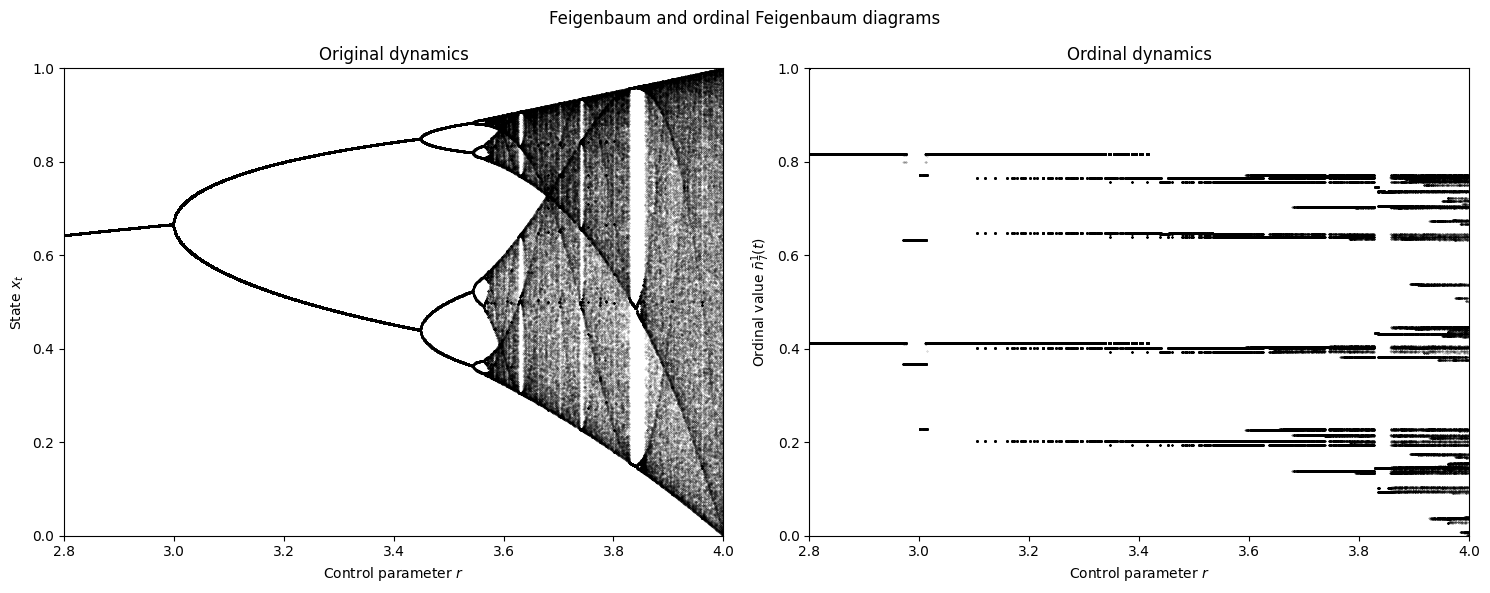

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

axes[0].scatter(
    raw_r_coordinates,
    orbits.ravel(),
    s=POINT_SIZE,
    alpha=POINT_ALPHA,
    color="black",
    rasterized=True,
)
axes[0].set(
    title="Original dynamics",
    xlabel=r"Control parameter $r$",
    ylabel=r"State $x_t$",
    xlim=(R_MIN, R_MAX),
    ylim=(0.0, 1.0),
)

axes[1].scatter(
    ordinal_r_coordinates,
    ordinal_orbits.ravel(),
    s=POINT_SIZE,
    alpha=POINT_ALPHA,
    color="black",
    rasterized=True,
)
axes[1].set(
    title="Ordinal dynamics",
    xlabel=r"Control parameter $r$",
    ylabel=r"Ordinal value $\bar{n}_7^1(t)$",
    xlim=(R_MIN, R_MAX),
    ylim=(0.0, 1.0),
)

fig.suptitle("Feigenbaum and ordinal Feigenbaum diagrams")
fig.tight_layout()
plt.show()

Các miền tuần hoàn vẫn có cấu trúc rõ ràng sau phép biến đổi. Quá trình period-doubling được bảo toàn về mặt định tính, trong khi các miền hỗn loạn sử dụng nhiều ordinal states hơn. Ordinal dynamics chỉ chiếm một tập con mỏng của $[0,1]$, phù hợp với mô tả của Keller và Sinn.

## 10. Diagnostic Analysis

Phần này không thuộc Figure 3 gốc. Support fraction đo tỷ lệ pattern quan sát được trên tổng số $(d+1)!$ pattern có thể có.

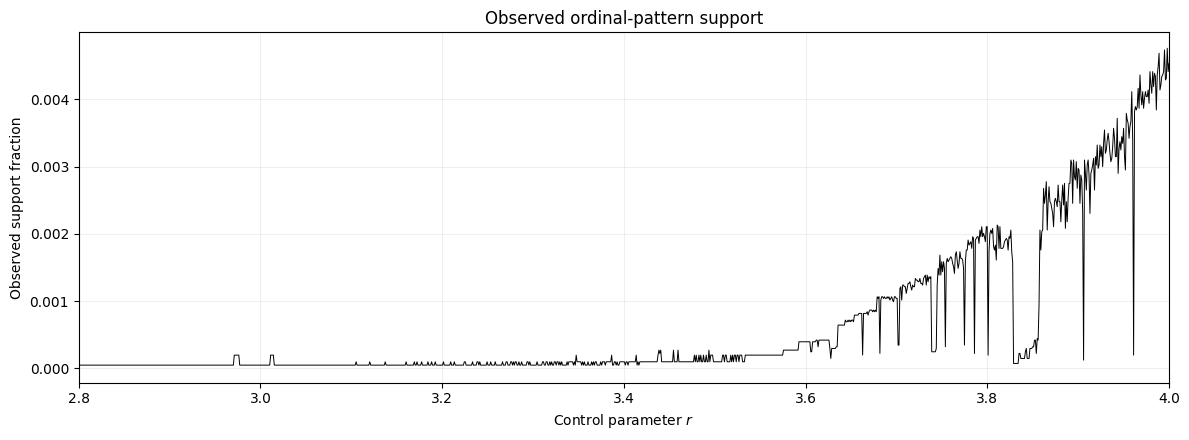

r=2.900: 2 observed patterns, support=0.000050
r=3.500: 4 observed patterns, support=0.000099
r=4.000: 183 observed patterns, support=0.004539


In [10]:
number_of_possible_patterns = factorial(D + 1)
support_fraction = (
    observed_pattern_counts / number_of_possible_patterns
)

fig, axis = plt.subplots(figsize=(12, 4.5))
axis.plot(r_values, support_fraction, color="black", linewidth=0.7)
axis.set(
    title="Observed ordinal-pattern support",
    xlabel=r"Control parameter $r$",
    ylabel="Observed support fraction",
    xlim=(R_MIN, R_MAX),
)
axis.grid(alpha=0.2)
fig.tight_layout()
plt.show()

for target_r in sanity_r_values:
    index = int(np.argmin(np.abs(r_values - target_r)))
    print(
        f"r={r_values[index]:.3f}: "
        f"{observed_pattern_counts[index]} observed patterns, "
        f"support={support_fraction[index]:.6f}"
    )

## 11. Reproduction Findings

### Reproduced

- Cấu trúc bifurcation của logistic map
- Cấu trúc bifurcation trong ordinal space
- Ordinal-state support bị giới hạn
- Sự tương ứng định tính giữa raw dynamics và ordinal dynamics

### Not exactly reproducible

- Mật độ và hình thức chính xác của Figure 3
- Điều kiện đầu ngẫu nhiên chính xác
- Số iterates được giữ lại
- Độ phân giải chính xác của parameter grid

Các chi tiết triển khai này không được paper báo cáo đầy đủ. Diagnostic support fraction chỉ nhằm giải thích độ mỏng của ordinal diagram và không được xem là kết quả gốc của paper.